# Part 2.1: OCT Retinal Images with MedMNIST — DCGAN

## Loading and Exploring the OCTMNIST Dataset

In [1]:
# Install the medmnist package (only needs to run once per environment)
!pip install medmnist --quiet

In [2]:
import medmnist
from medmnist import OCTMNIST
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

torch.manual_seed(42)

print(f"medmnist version: {medmnist.__version__}")

# OCTMNIST info: 4 classes of retinal OCT conditions, grayscale 28x28 images
info = medmnist.INFO["octmnist"]
print("Task:", info["task"])
print("Number of classes:", len(info["label"]))
print("Class labels:", info["label"])

medmnist version: 3.0.2
Task: multi-class
Number of classes: 4
Class labels: {'0': 'choroidal neovascularization', '1': 'diabetic macular edema', '2': 'drusen', '3': 'normal'}


### Downloading and Loading the Dataset

We use the built-in train split and apply a simple normalisation transform
(scaling pixel values to [-1, 1], which works well with `Tanh` generator outputs later).

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # scales [0,1] -> [-1,1]
])

train_dataset = OCTMNIST(split="train", transform=transform, download=True)

print(f"Number of training images: {len(train_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")

Number of training images: 97477
Image shape: torch.Size([1, 28, 28])


### Class Distribution

Class 0 (choroidal neovascularization): 33484 images (34.4%)
Class 1 (diabetic macular edema): 10213 images (10.5%)
Class 2 (drusen): 7754 images (8.0%)
Class 3 (normal): 46026 images (47.2%)


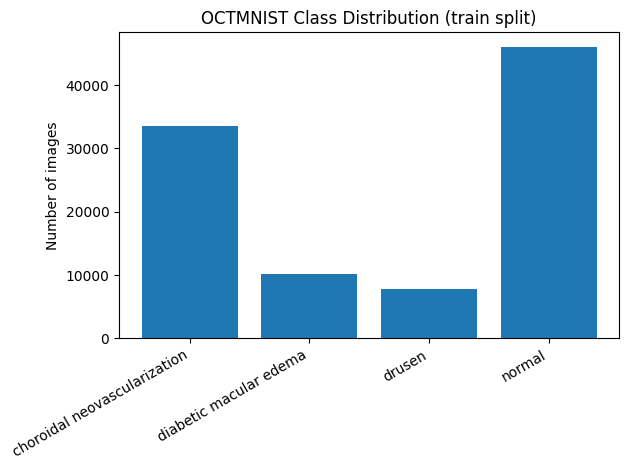

In [4]:
labels = np.array([train_dataset[i][1][0] for i in range(len(train_dataset))])
unique, counts = np.unique(labels, return_counts=True)

for cls, count in zip(unique, counts):
    class_name = info["label"][str(cls)]
    print(f"Class {cls} ({class_name}): {count} images ({count/len(labels):.1%})")

plt.bar([info["label"][str(c)] for c in unique], counts)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Number of images")
plt.title("OCTMNIST Class Distribution (train split)")
plt.tight_layout()
plt.show()

### Sample Images

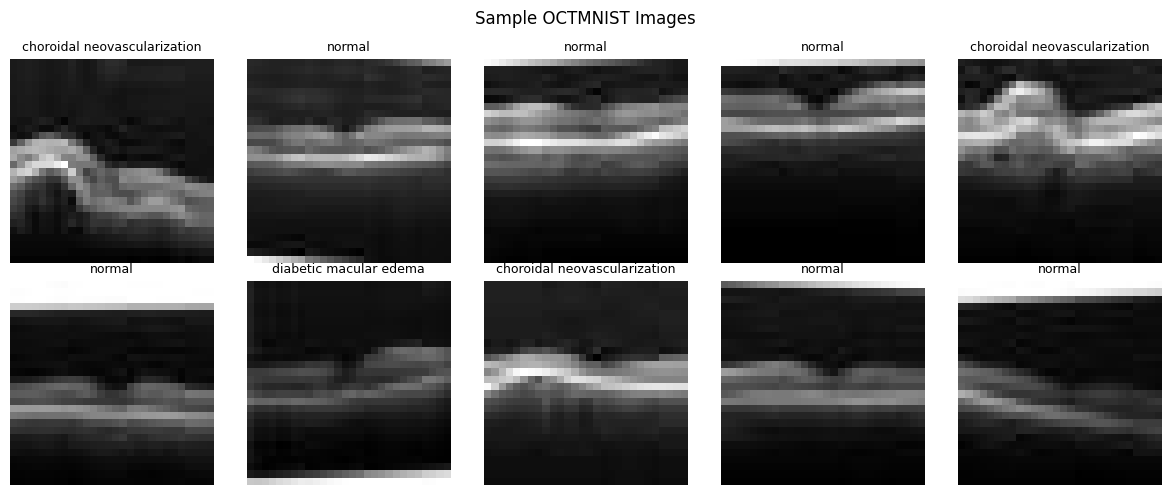

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    img_np = img.squeeze().numpy()
    img_np = (img_np * 0.5) + 0.5  # undo normalisation for display
    ax.imshow(img_np, cmap="gray")
    ax.set_title(info["label"][str(label[0])], fontsize=9)
    ax.axis("off")
plt.suptitle("Sample OCTMNIST Images")
plt.tight_layout()
plt.show()

## Building the DCGAN

Following standard DCGAN conventions (Radford et al., 2015):
- Generator: transposed convolutions to upsample from a latent vector to a 28×28 image, BatchNorm + ReLU, Tanh output (matches our [-1, 1] normalisation)
- Discriminator: strided convolutions to downsample the image to a single probability, BatchNorm + LeakyReLU, Sigmoid output

In [6]:
from torch import nn

latent_dim = 100  # size of the random noise vector fed to the generator

class DCGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            # Input: (latent_dim, 1, 1) -> (128, 7, 7)
            nn.ConvTranspose2d(latent_dim, 128, kernel_size=7, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # (128, 7, 7) -> (64, 14, 14)
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # (64, 14, 14) -> (1, 28, 28)
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        # z arrives as (batch, latent_dim) -> reshape to (batch, latent_dim, 1, 1)
        z = z.view(z.size(0), -1, 1, 1)
        return self.model(z)


class DCDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # (1, 28, 28) -> (64, 14, 14)
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # (64, 14, 14) -> (128, 7, 7)
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # (128, 7, 7) -> (1, 1, 1)
            nn.Conv2d(128, 1, kernel_size=7, stride=1, padding=0, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        output = self.model(x)
        return output.view(-1, 1)  # flatten to (batch, 1)


dc_generator = DCGenerator(latent_dim)
dc_discriminator = DCDiscriminator()

# Quick sanity check: does the shape pipeline work end to end?
test_noise = torch.randn(4, latent_dim)
test_fake = dc_generator(test_noise)
test_output = dc_discriminator(test_fake)
print("Generator output shape:", test_fake.shape)   # should be (4, 1, 28, 28)
print("Discriminator output shape:", test_output.shape)  # should be (4, 1)

Generator output shape: torch.Size([4, 1, 28, 28])
Discriminator output shape: torch.Size([4, 1])


## Training the DCGAN

In [7]:
from torch.utils.data import DataLoader

batch_size = 128
num_epochs = 20  # DCGANs converge much faster per-image than the small MLP GANs in Part 1

train_loader_oct = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

loss_function = nn.BCELoss()
lr = 0.0002  # standard DCGAN learning rate (Radford et al.)
beta1 = 0.5  # standard DCGAN Adam momentum term

optimizer_g = torch.optim.Adam(dc_generator.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_d = torch.optim.Adam(dc_discriminator.parameters(), lr=lr, betas=(beta1, 0.999))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dc_generator.to(device)
dc_discriminator.to(device)
print("Using device:", device)

Using device: cuda


Epoch [1/20] Batch [0/762] Loss D: 1.4347 Loss G: 0.7606
Epoch [1/20] Batch [200/762] Loss D: 0.0017 Loss G: 6.8632
Epoch [1/20] Batch [400/762] Loss D: 0.0004 Loss G: 8.3569
Epoch [1/20] Batch [600/762] Loss D: 0.8065 Loss G: 1.2411


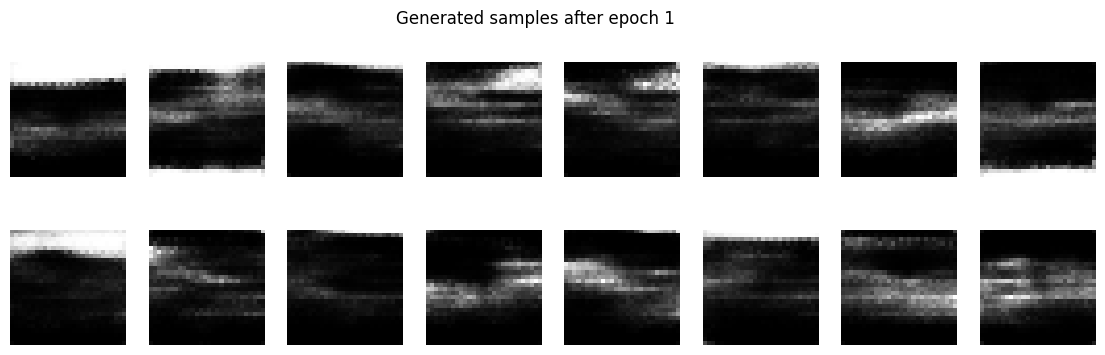

Epoch [2/20] Batch [0/762] Loss D: 0.7576 Loss G: 2.9675
Epoch [2/20] Batch [200/762] Loss D: 0.4979 Loss G: 1.5771
Epoch [2/20] Batch [400/762] Loss D: 0.4294 Loss G: 2.3691
Epoch [2/20] Batch [600/762] Loss D: 0.9380 Loss G: 1.6553


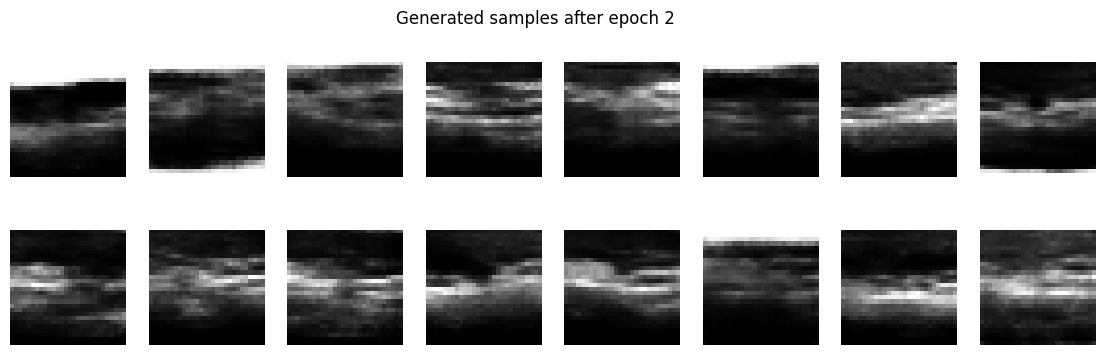

Epoch [3/20] Batch [0/762] Loss D: 0.3297 Loss G: 2.1876
Epoch [3/20] Batch [200/762] Loss D: 0.5751 Loss G: 2.3076
Epoch [3/20] Batch [400/762] Loss D: 0.1851 Loss G: 2.8073
Epoch [3/20] Batch [600/762] Loss D: 0.1771 Loss G: 2.8226


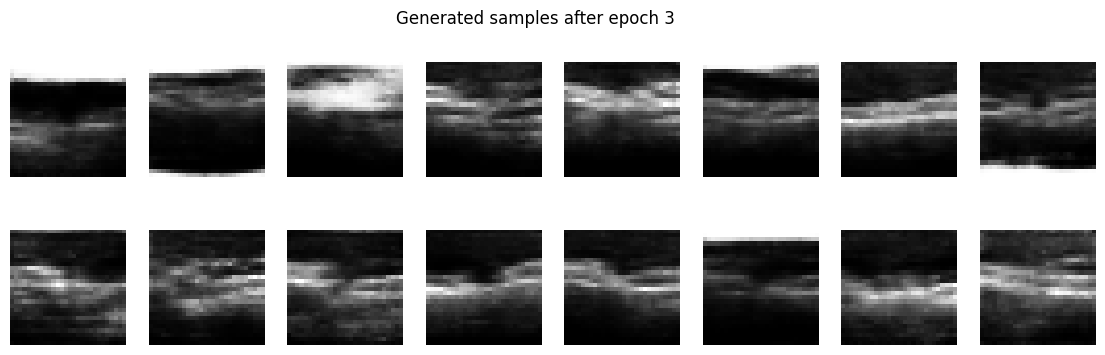

Epoch [4/20] Batch [0/762] Loss D: 0.4648 Loss G: 4.1423
Epoch [4/20] Batch [200/762] Loss D: 0.2691 Loss G: 2.2476
Epoch [4/20] Batch [400/762] Loss D: 0.1731 Loss G: 2.9582
Epoch [4/20] Batch [600/762] Loss D: 0.7929 Loss G: 0.8920


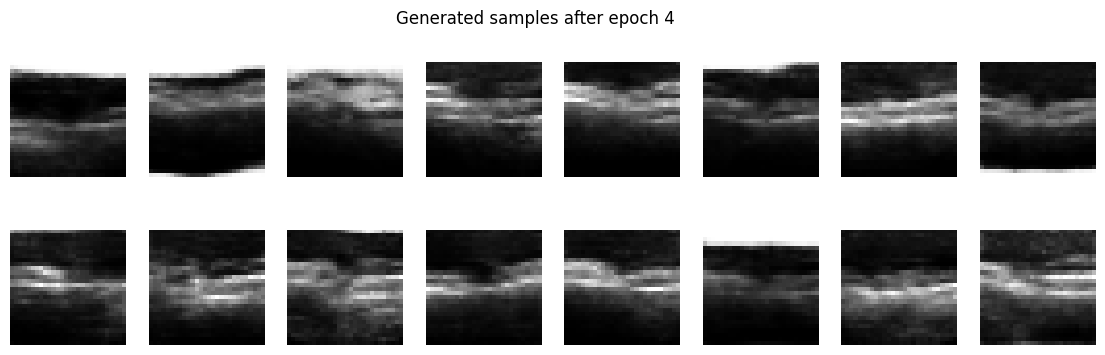

Epoch [5/20] Batch [0/762] Loss D: 0.4878 Loss G: 2.2437
Epoch [5/20] Batch [200/762] Loss D: 0.2552 Loss G: 2.8539
Epoch [5/20] Batch [400/762] Loss D: 0.2434 Loss G: 3.1375
Epoch [5/20] Batch [600/762] Loss D: 0.2839 Loss G: 2.5865


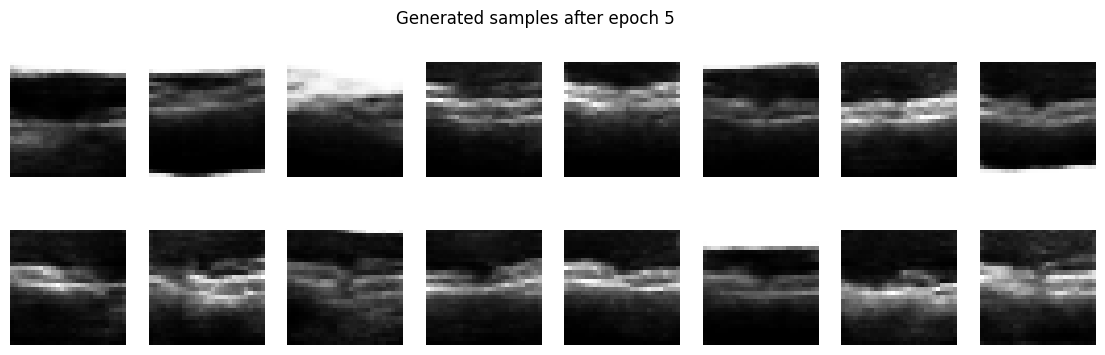

Epoch [6/20] Batch [0/762] Loss D: 0.1546 Loss G: 2.6495
Epoch [6/20] Batch [200/762] Loss D: 0.3501 Loss G: 2.3384
Epoch [6/20] Batch [400/762] Loss D: 0.4957 Loss G: 1.9041
Epoch [6/20] Batch [600/762] Loss D: 0.1884 Loss G: 3.2035


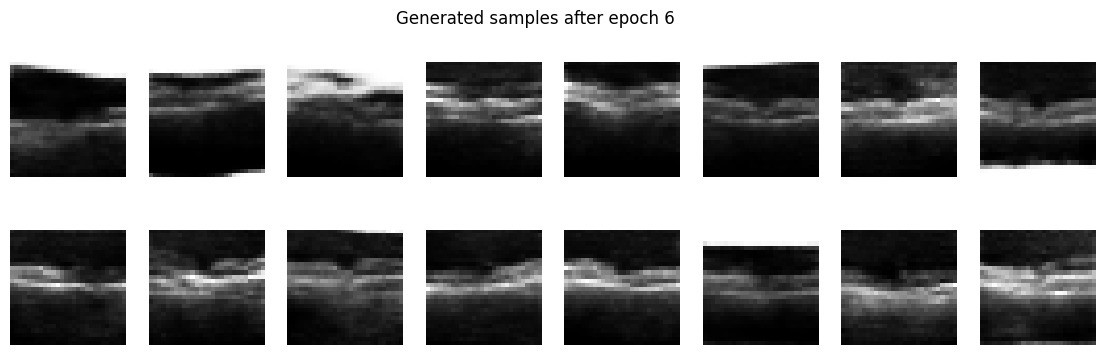

Epoch [7/20] Batch [0/762] Loss D: 0.3215 Loss G: 2.8663
Epoch [7/20] Batch [200/762] Loss D: 0.4327 Loss G: 2.5458
Epoch [7/20] Batch [400/762] Loss D: 0.2546 Loss G: 2.1290
Epoch [7/20] Batch [600/762] Loss D: 0.2421 Loss G: 2.9146


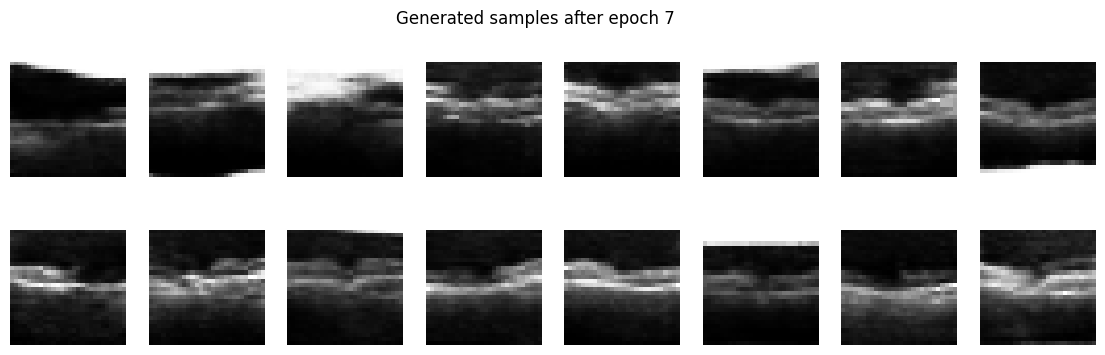

Epoch [8/20] Batch [0/762] Loss D: 1.0613 Loss G: 2.3036
Epoch [8/20] Batch [200/762] Loss D: 0.3470 Loss G: 2.1611
Epoch [8/20] Batch [400/762] Loss D: 0.3471 Loss G: 2.5247
Epoch [8/20] Batch [600/762] Loss D: 0.6720 Loss G: 4.4882


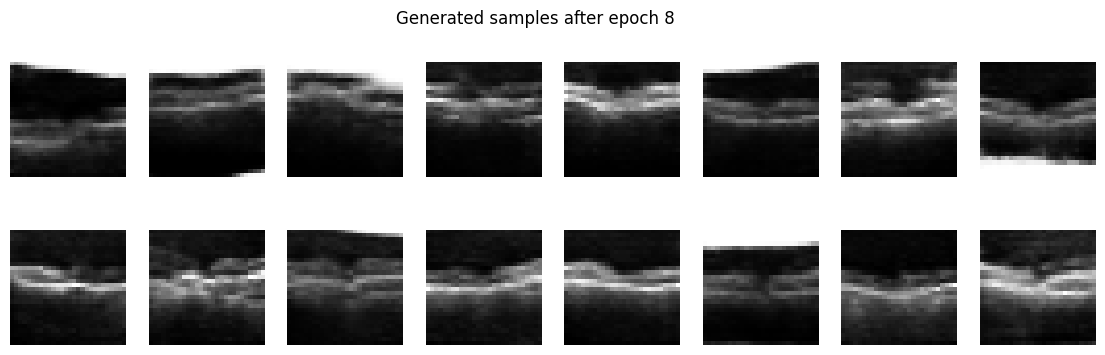

Epoch [9/20] Batch [0/762] Loss D: 0.6206 Loss G: 3.7148
Epoch [9/20] Batch [200/762] Loss D: 0.1899 Loss G: 3.0540
Epoch [9/20] Batch [400/762] Loss D: 0.1852 Loss G: 2.5782
Epoch [9/20] Batch [600/762] Loss D: 0.1180 Loss G: 3.6367


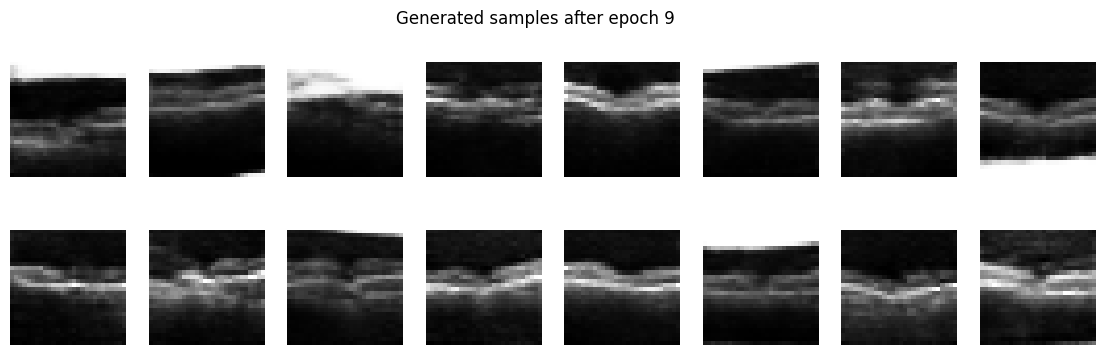

Epoch [10/20] Batch [0/762] Loss D: 0.6989 Loss G: 1.7107
Epoch [10/20] Batch [200/762] Loss D: 0.3167 Loss G: 2.9586
Epoch [10/20] Batch [400/762] Loss D: 0.5347 Loss G: 0.9676
Epoch [10/20] Batch [600/762] Loss D: 0.2274 Loss G: 2.3211


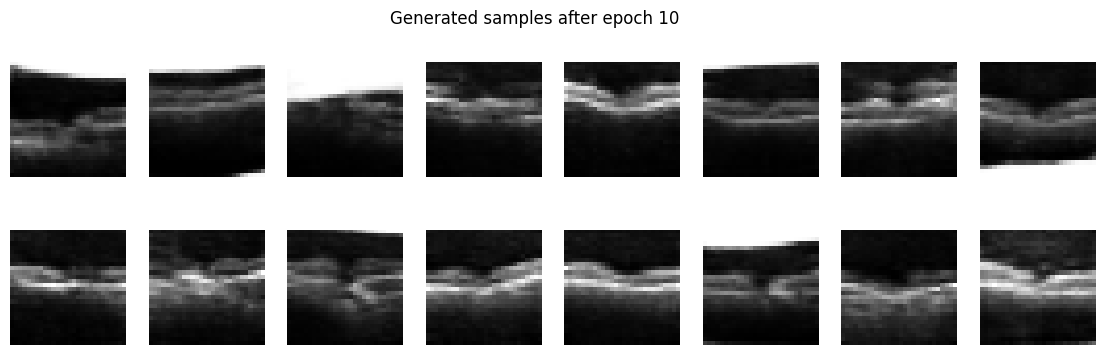

Epoch [11/20] Batch [0/762] Loss D: 0.2655 Loss G: 3.0544
Epoch [11/20] Batch [200/762] Loss D: 0.1245 Loss G: 3.6267
Epoch [11/20] Batch [400/762] Loss D: 0.1176 Loss G: 3.5699
Epoch [11/20] Batch [600/762] Loss D: 0.2867 Loss G: 2.9149


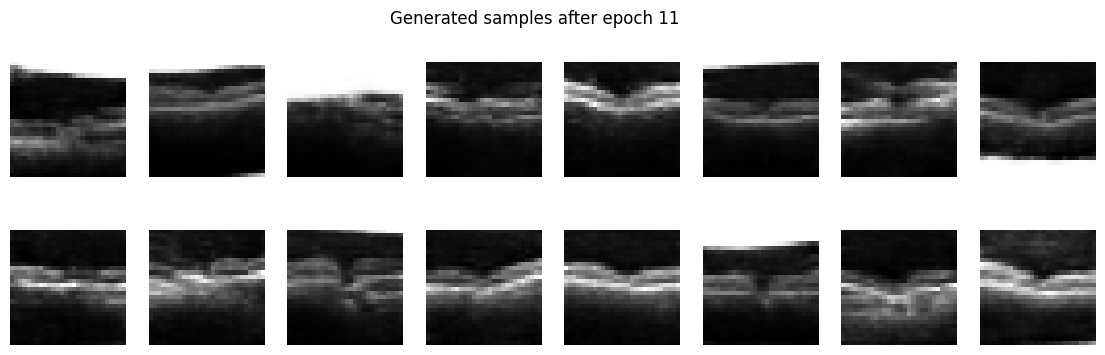

Epoch [12/20] Batch [0/762] Loss D: 0.2742 Loss G: 3.0254
Epoch [12/20] Batch [200/762] Loss D: 0.5855 Loss G: 1.5295
Epoch [12/20] Batch [400/762] Loss D: 0.3037 Loss G: 3.0043
Epoch [12/20] Batch [600/762] Loss D: 0.1891 Loss G: 3.1548


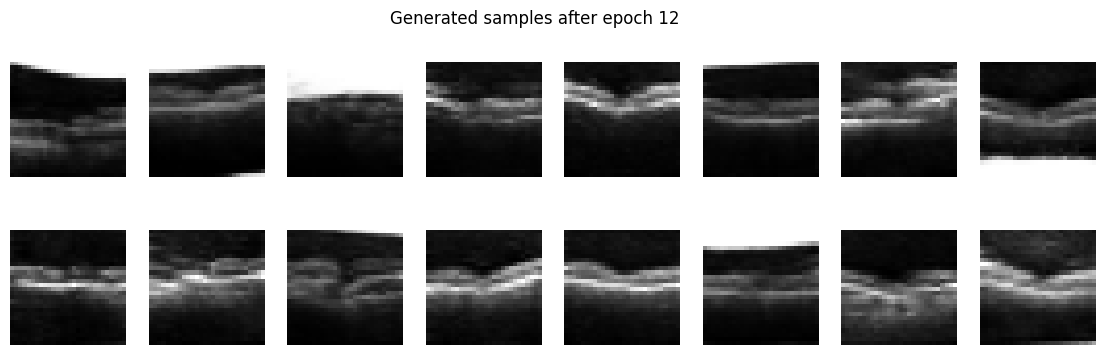

Epoch [13/20] Batch [0/762] Loss D: 0.1898 Loss G: 3.4234
Epoch [13/20] Batch [200/762] Loss D: 0.1674 Loss G: 3.1981
Epoch [13/20] Batch [400/762] Loss D: 0.4620 Loss G: 2.1967
Epoch [13/20] Batch [600/762] Loss D: 0.2176 Loss G: 2.8924


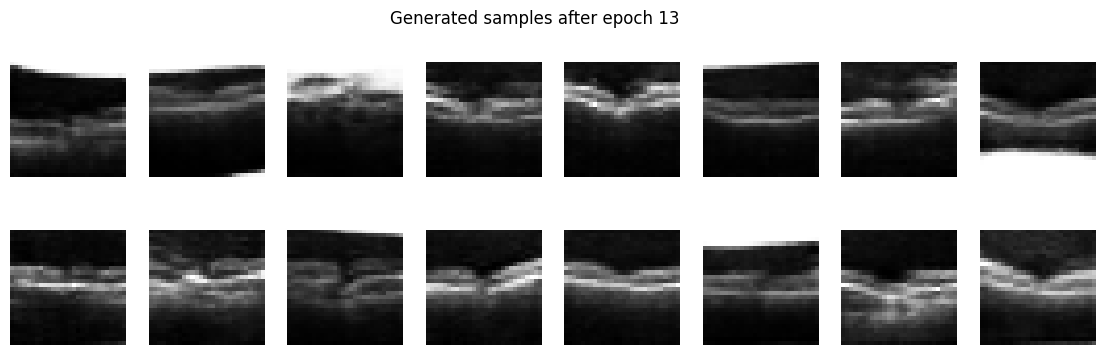

Epoch [14/20] Batch [0/762] Loss D: 1.4115 Loss G: 7.6776
Epoch [14/20] Batch [200/762] Loss D: 0.0638 Loss G: 4.3191
Epoch [14/20] Batch [400/762] Loss D: 0.1953 Loss G: 2.4049
Epoch [14/20] Batch [600/762] Loss D: 0.4724 Loss G: 3.3066


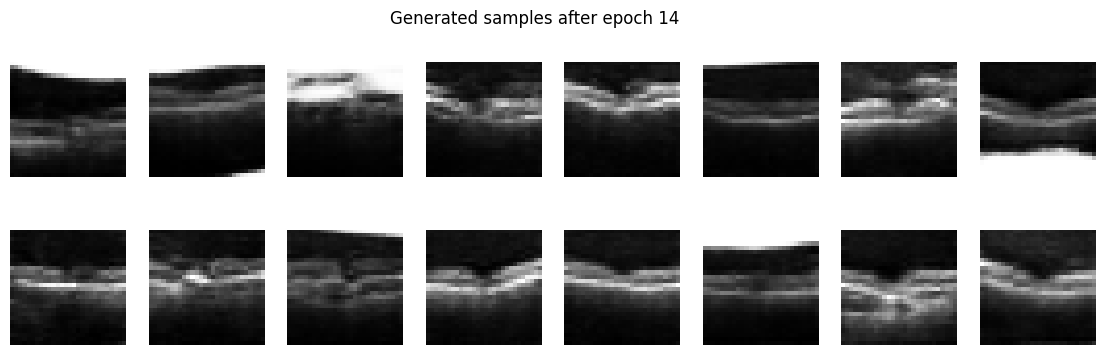

Epoch [15/20] Batch [0/762] Loss D: 0.1507 Loss G: 3.2948
Epoch [15/20] Batch [200/762] Loss D: 0.2148 Loss G: 2.9807
Epoch [15/20] Batch [400/762] Loss D: 0.0795 Loss G: 4.6269
Epoch [15/20] Batch [600/762] Loss D: 0.1974 Loss G: 3.4921


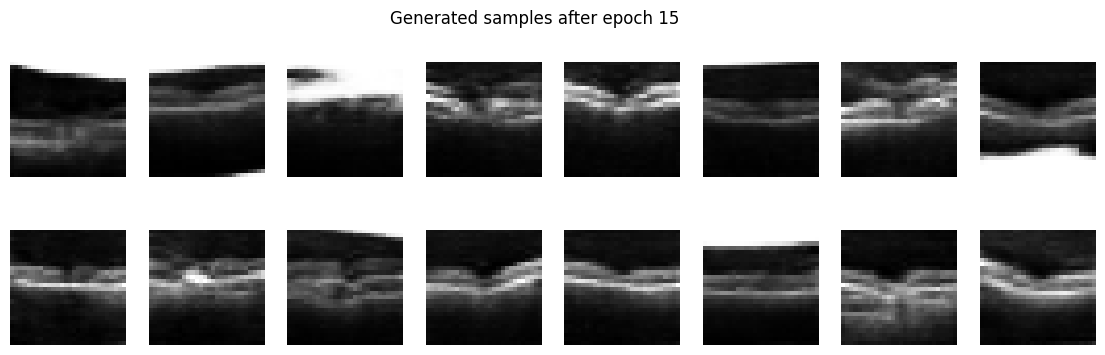

Epoch [16/20] Batch [0/762] Loss D: 0.5798 Loss G: 3.8793
Epoch [16/20] Batch [200/762] Loss D: 0.8502 Loss G: 3.5576
Epoch [16/20] Batch [400/762] Loss D: 0.1175 Loss G: 4.7187
Epoch [16/20] Batch [600/762] Loss D: 0.2092 Loss G: 3.9804


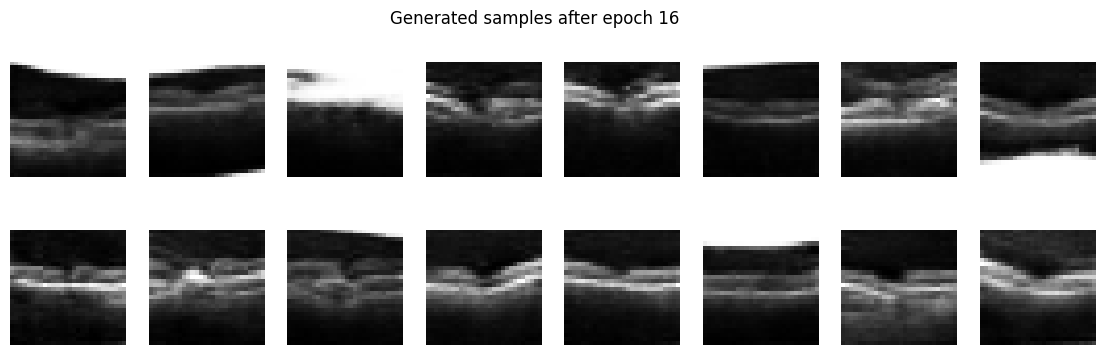

Epoch [17/20] Batch [0/762] Loss D: 0.3030 Loss G: 1.9975
Epoch [17/20] Batch [200/762] Loss D: 0.1879 Loss G: 3.1388
Epoch [17/20] Batch [400/762] Loss D: 0.2081 Loss G: 3.1535
Epoch [17/20] Batch [600/762] Loss D: 0.4112 Loss G: 1.9843


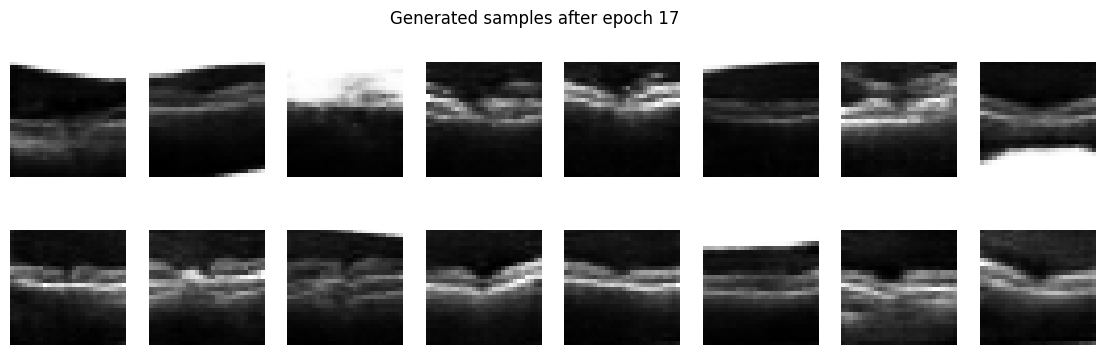

Epoch [18/20] Batch [0/762] Loss D: 0.2493 Loss G: 4.1271
Epoch [18/20] Batch [200/762] Loss D: 0.2295 Loss G: 3.8559
Epoch [18/20] Batch [400/762] Loss D: 0.4020 Loss G: 2.0027
Epoch [18/20] Batch [600/762] Loss D: 0.5935 Loss G: 2.3079


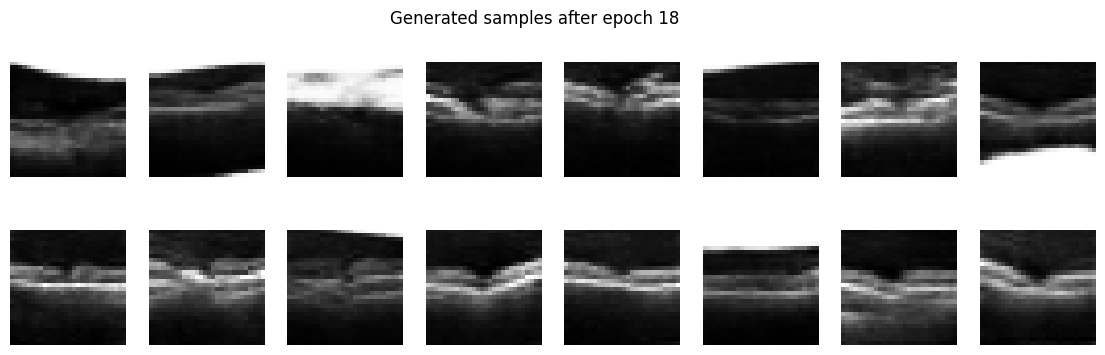

Epoch [19/20] Batch [0/762] Loss D: 0.3930 Loss G: 5.0053
Epoch [19/20] Batch [200/762] Loss D: 0.2477 Loss G: 2.4068
Epoch [19/20] Batch [400/762] Loss D: 0.1804 Loss G: 3.6730
Epoch [19/20] Batch [600/762] Loss D: 0.2595 Loss G: 2.8740


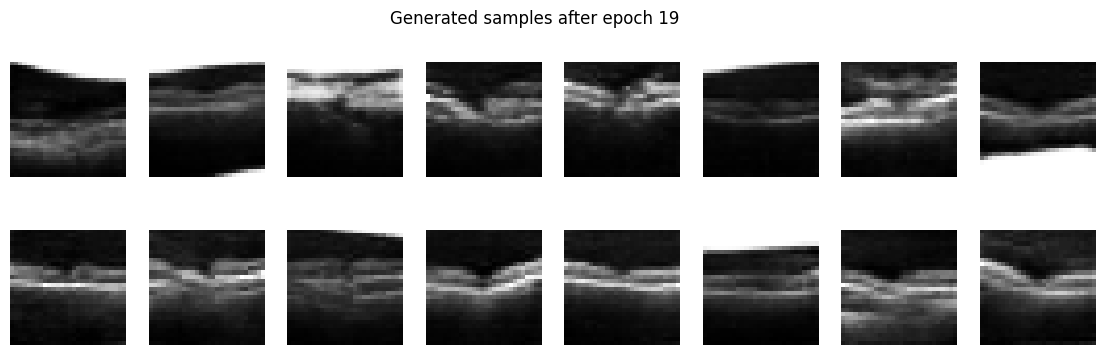

Epoch [20/20] Batch [0/762] Loss D: 0.2270 Loss G: 2.8154
Epoch [20/20] Batch [200/762] Loss D: 0.4448 Loss G: 1.7940
Epoch [20/20] Batch [400/762] Loss D: 0.1384 Loss G: 3.6620
Epoch [20/20] Batch [600/762] Loss D: 0.8235 Loss G: 6.3263


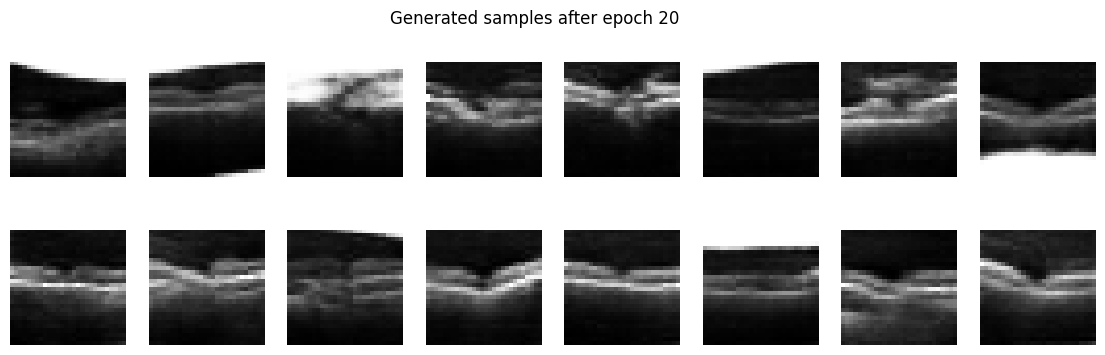

In [8]:
d_losses_oct = []
g_losses_oct = []

fixed_noise = torch.randn(16, latent_dim, device=device)  # fixed noise to track progress visually across epochs

for epoch in range(num_epochs):
    for i, (real_images, _) in enumerate(train_loader_oct):
        real_images = real_images.to(device)
        current_batch_size = real_images.size(0)

        real_labels = torch.ones(current_batch_size, 1, device=device)
        fake_labels = torch.zeros(current_batch_size, 1, device=device)

        # --- Train Discriminator ---
        optimizer_d.zero_grad()

        output_real = dc_discriminator(real_images)
        loss_d_real = loss_function(output_real, real_labels)

        noise = torch.randn(current_batch_size, latent_dim, device=device)
        fake_images = dc_generator(noise)
        output_fake = dc_discriminator(fake_images.detach())
        loss_d_fake = loss_function(output_fake, fake_labels)

        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        optimizer_d.step()

        # --- Train Generator ---
        optimizer_g.zero_grad()
        output_fake_for_g = dc_discriminator(fake_images)
        loss_g = loss_function(output_fake_for_g, real_labels)  # wants discriminator to think these are real
        loss_g.backward()
        optimizer_g.step()

        if i % 200 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] Batch [{i}/{len(train_loader_oct)}] "
                  f"Loss D: {loss_d.item():.4f} Loss G: {loss_g.item():.4f}")

    d_losses_oct.append(loss_d.item())
    g_losses_oct.append(loss_g.item())

    # Show generated samples at the end of each epoch to visually track progress
    with torch.no_grad():
        sample_imgs = dc_generator(fixed_noise).cpu()
    fig, axes = plt.subplots(2, 8, figsize=(14, 4))
    for idx, ax in enumerate(axes.flat):
        img = sample_imgs[idx].squeeze().numpy()
        img = (img * 0.5) + 0.5  # undo Tanh normalisation for display
        ax.imshow(img, cmap="gray")
        ax.axis("off")
    plt.suptitle(f"Generated samples after epoch {epoch+1}")
    plt.show()

## Continued Training (20 more epochs)

Based on the epoch-20 checkpoint analysis, the generator was still mid-convergence
(structure metric still climbing, no sign of collapse). We continue training the
same models for a further 20 epochs rather than restarting from scratch.

Epoch [21/40] Batch [0/762] Loss D: 0.1349 Loss G: 4.4617
Epoch [21/40] Batch [200/762] Loss D: 1.0295 Loss G: 1.1719
Epoch [21/40] Batch [400/762] Loss D: 0.2142 Loss G: 3.5672
Epoch [21/40] Batch [600/762] Loss D: 0.1167 Loss G: 3.5726


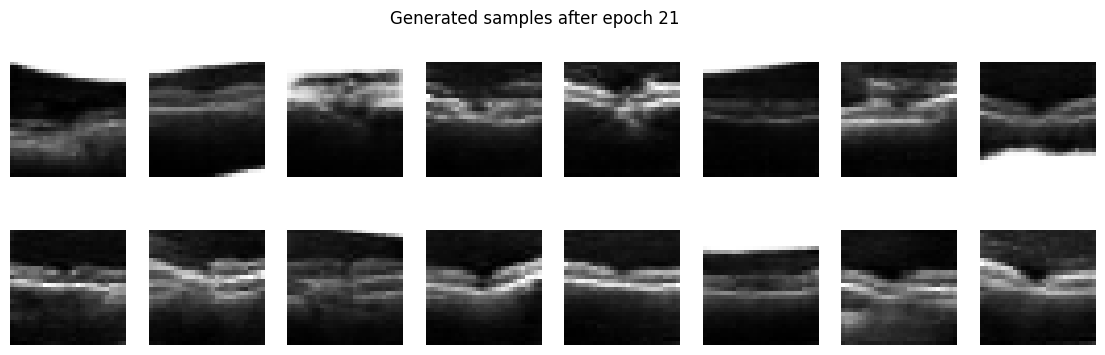

Epoch [22/40] Batch [0/762] Loss D: 0.8176 Loss G: 3.2319
Epoch [22/40] Batch [200/762] Loss D: 0.4275 Loss G: 3.5679
Epoch [22/40] Batch [400/762] Loss D: 0.3056 Loss G: 3.0792
Epoch [22/40] Batch [600/762] Loss D: 0.1365 Loss G: 4.2521


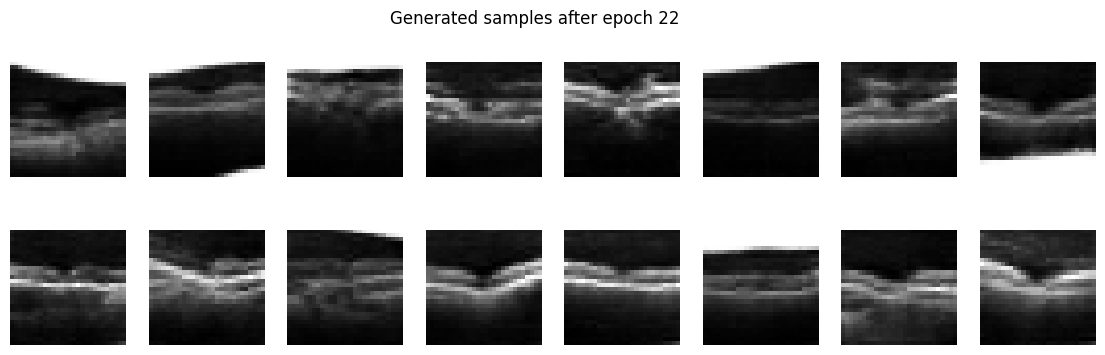

Epoch [23/40] Batch [0/762] Loss D: 0.2214 Loss G: 4.4254
Epoch [23/40] Batch [200/762] Loss D: 0.3608 Loss G: 2.2817
Epoch [23/40] Batch [400/762] Loss D: 0.1761 Loss G: 3.6153
Epoch [23/40] Batch [600/762] Loss D: 1.0626 Loss G: 1.9283


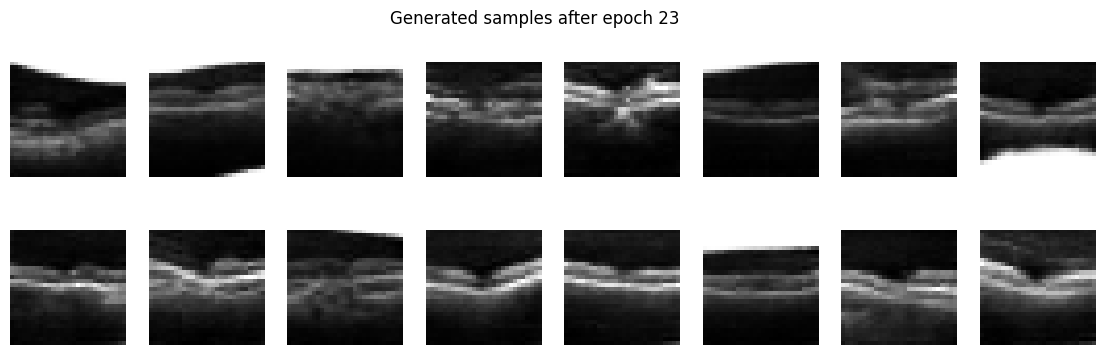

Epoch [24/40] Batch [0/762] Loss D: 0.2096 Loss G: 3.7395
Epoch [24/40] Batch [200/762] Loss D: 0.2196 Loss G: 2.6881
Epoch [24/40] Batch [400/762] Loss D: 0.3297 Loss G: 3.2762
Epoch [24/40] Batch [600/762] Loss D: 0.0883 Loss G: 3.3253


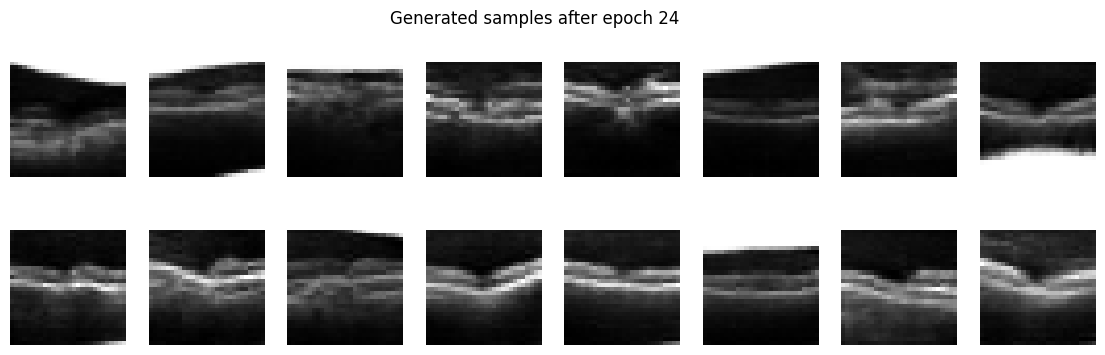

Epoch [25/40] Batch [0/762] Loss D: 0.4259 Loss G: 5.1920
Epoch [25/40] Batch [200/762] Loss D: 0.1252 Loss G: 4.3266
Epoch [25/40] Batch [400/762] Loss D: 0.1083 Loss G: 4.4803
Epoch [25/40] Batch [600/762] Loss D: 0.4250 Loss G: 3.1346


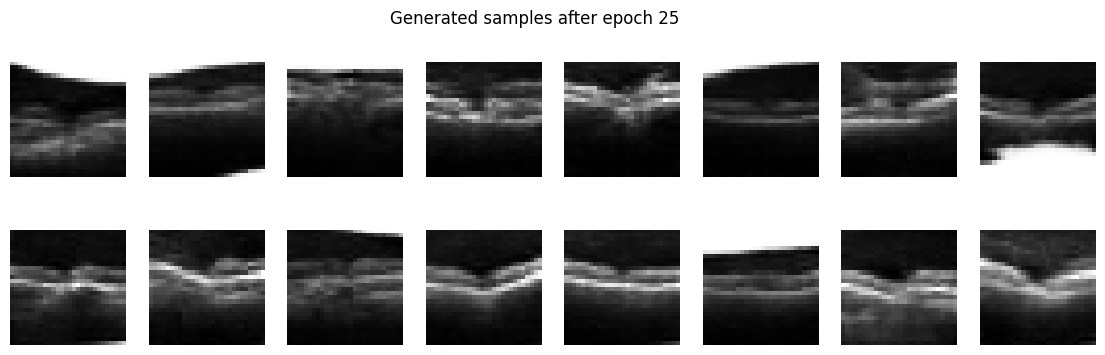

Epoch [26/40] Batch [0/762] Loss D: 0.6101 Loss G: 1.8519
Epoch [26/40] Batch [200/762] Loss D: 0.1176 Loss G: 3.8440
Epoch [26/40] Batch [400/762] Loss D: 0.2571 Loss G: 3.5041
Epoch [26/40] Batch [600/762] Loss D: 0.2158 Loss G: 3.6018


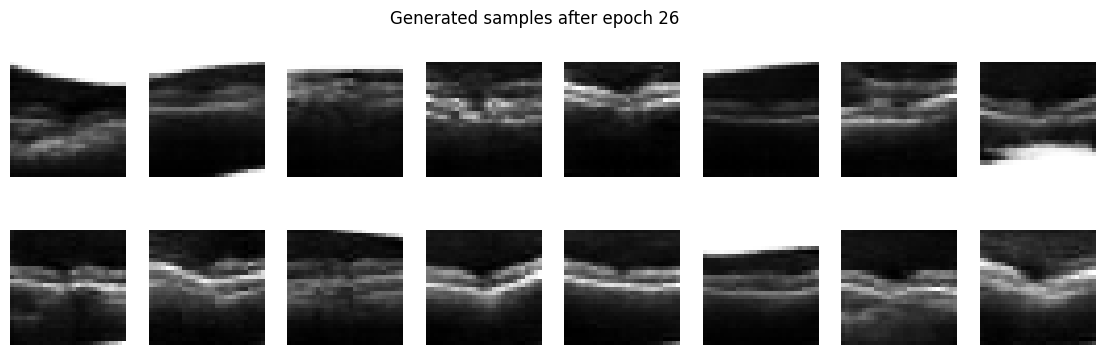

Epoch [27/40] Batch [0/762] Loss D: 0.1865 Loss G: 3.4143
Epoch [27/40] Batch [200/762] Loss D: 0.5265 Loss G: 2.0253
Epoch [27/40] Batch [400/762] Loss D: 0.1353 Loss G: 4.4418
Epoch [27/40] Batch [600/762] Loss D: 0.1310 Loss G: 3.8327


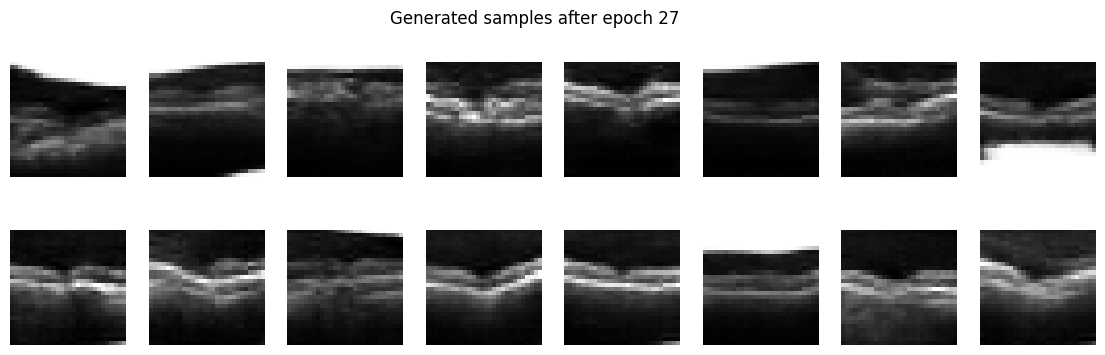

Epoch [28/40] Batch [0/762] Loss D: 0.1159 Loss G: 3.7518
Epoch [28/40] Batch [200/762] Loss D: 0.0954 Loss G: 4.2837
Epoch [28/40] Batch [400/762] Loss D: 0.1963 Loss G: 2.7605
Epoch [28/40] Batch [600/762] Loss D: 0.2512 Loss G: 2.8999


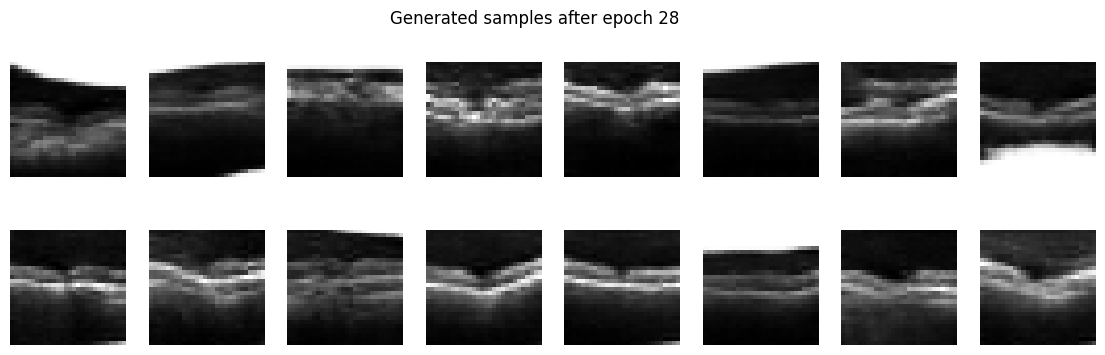

Epoch [29/40] Batch [0/762] Loss D: 0.1120 Loss G: 4.4386
Epoch [29/40] Batch [200/762] Loss D: 0.1464 Loss G: 3.9187
Epoch [29/40] Batch [400/762] Loss D: 0.4164 Loss G: 3.3196
Epoch [29/40] Batch [600/762] Loss D: 0.2672 Loss G: 3.9577


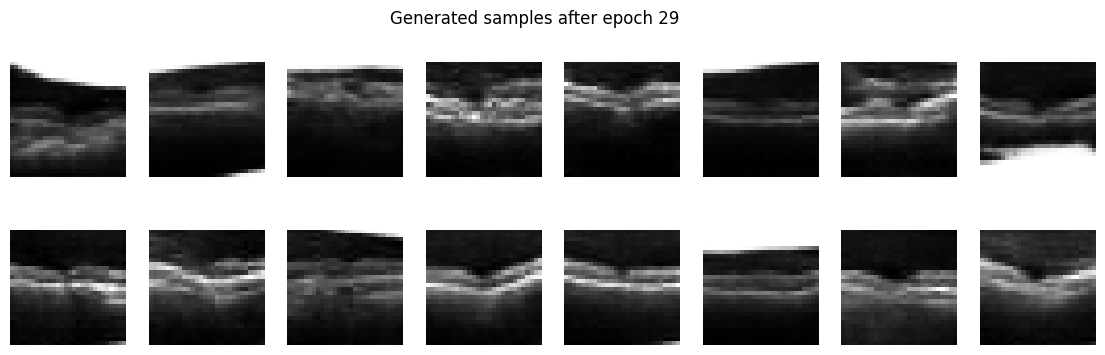

Epoch [30/40] Batch [0/762] Loss D: 0.3260 Loss G: 4.3629
Epoch [30/40] Batch [200/762] Loss D: 0.2463 Loss G: 3.5216
Epoch [30/40] Batch [400/762] Loss D: 0.0535 Loss G: 4.0648
Epoch [30/40] Batch [600/762] Loss D: 0.3236 Loss G: 2.8340


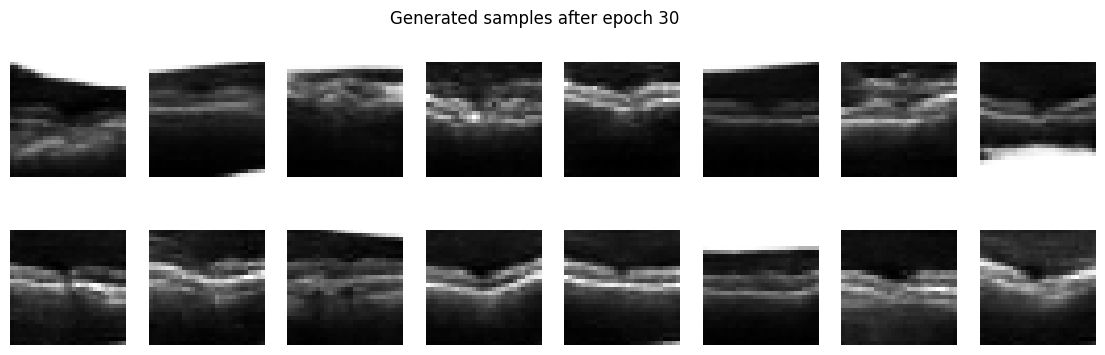

Epoch [31/40] Batch [0/762] Loss D: 0.1737 Loss G: 4.2390
Epoch [31/40] Batch [200/762] Loss D: 0.2416 Loss G: 3.6857
Epoch [31/40] Batch [400/762] Loss D: 0.1251 Loss G: 3.6600
Epoch [31/40] Batch [600/762] Loss D: 0.1177 Loss G: 4.1011


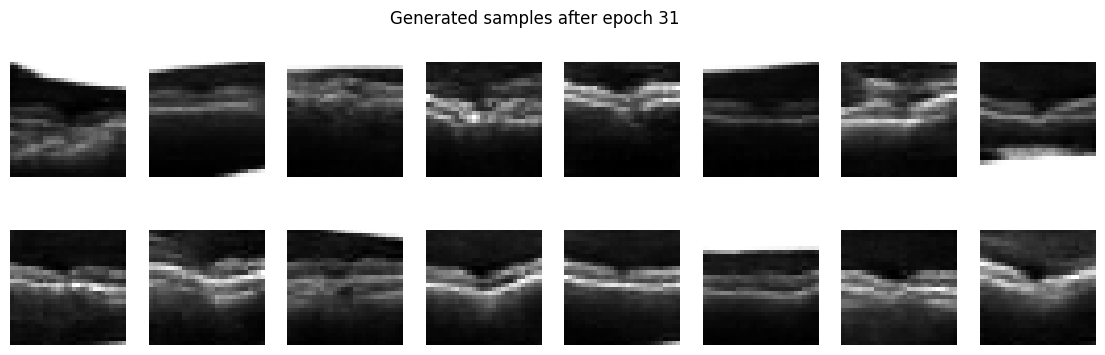

Epoch [32/40] Batch [0/762] Loss D: 0.2306 Loss G: 5.0361
Epoch [32/40] Batch [200/762] Loss D: 0.3206 Loss G: 2.8734
Epoch [32/40] Batch [400/762] Loss D: 0.2506 Loss G: 4.5802
Epoch [32/40] Batch [600/762] Loss D: 0.5578 Loss G: 1.7109


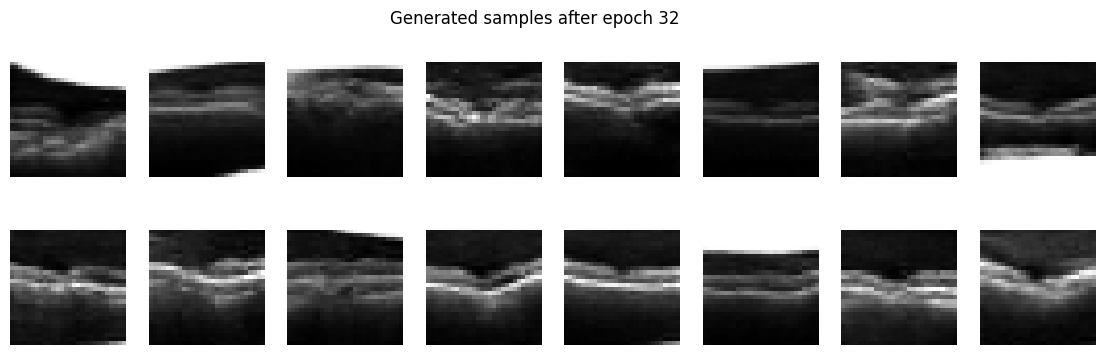

Epoch [33/40] Batch [0/762] Loss D: 0.1092 Loss G: 4.9502
Epoch [33/40] Batch [200/762] Loss D: 0.2505 Loss G: 2.7325
Epoch [33/40] Batch [400/762] Loss D: 0.1287 Loss G: 4.1687
Epoch [33/40] Batch [600/762] Loss D: 0.1599 Loss G: 3.8260


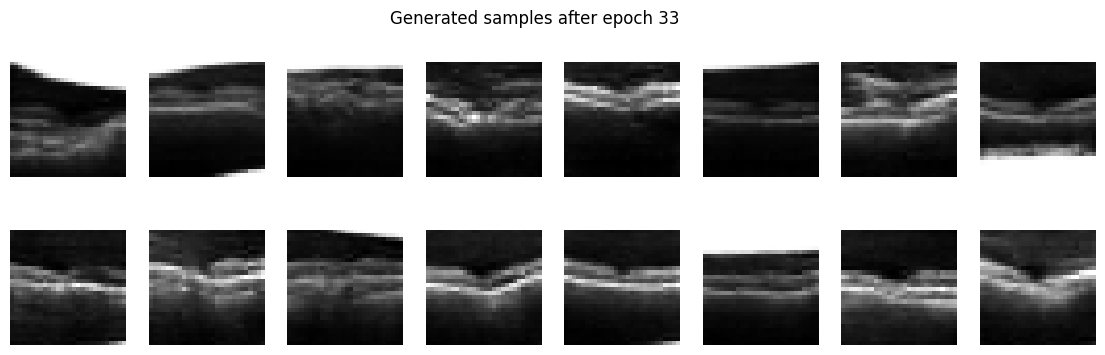

Epoch [34/40] Batch [0/762] Loss D: 0.2240 Loss G: 3.2747
Epoch [34/40] Batch [200/762] Loss D: 0.1733 Loss G: 3.1104
Epoch [34/40] Batch [400/762] Loss D: 0.2815 Loss G: 3.8366
Epoch [34/40] Batch [600/762] Loss D: 0.1216 Loss G: 4.7761


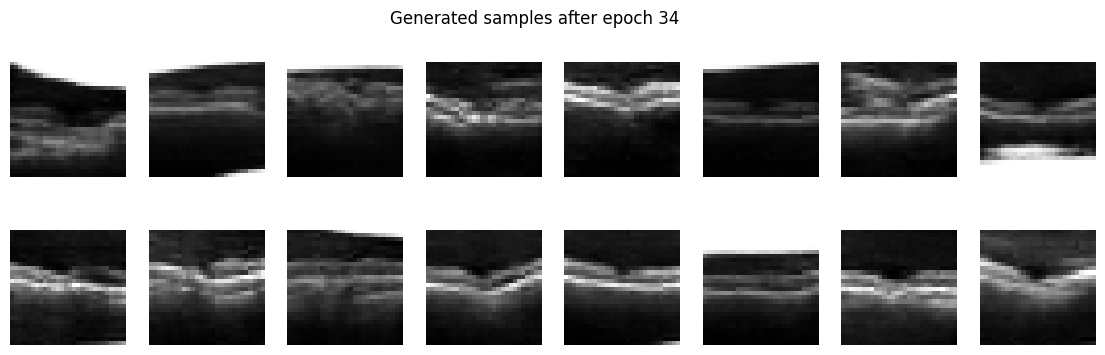

Epoch [35/40] Batch [0/762] Loss D: 0.2798 Loss G: 2.4242
Epoch [35/40] Batch [200/762] Loss D: 0.2341 Loss G: 3.7092
Epoch [35/40] Batch [400/762] Loss D: 0.0879 Loss G: 4.3996
Epoch [35/40] Batch [600/762] Loss D: 0.1230 Loss G: 4.1809


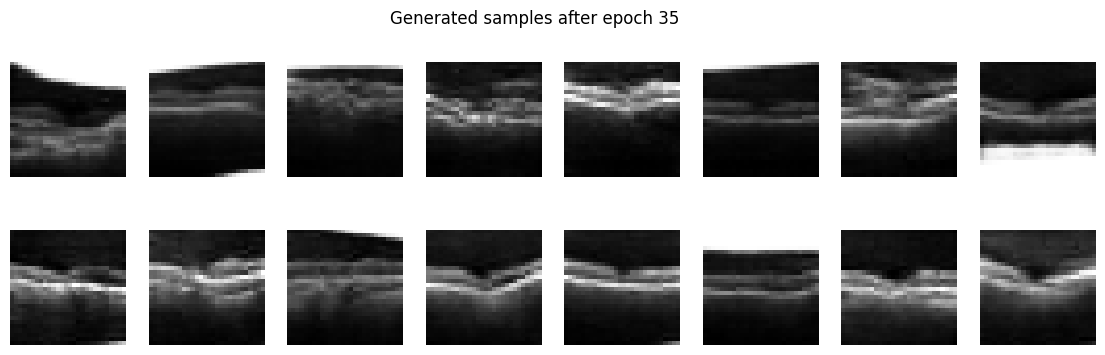

Epoch [36/40] Batch [0/762] Loss D: 0.1798 Loss G: 3.2313
Epoch [36/40] Batch [200/762] Loss D: 0.1976 Loss G: 3.8981
Epoch [36/40] Batch [400/762] Loss D: 0.2868 Loss G: 3.2483
Epoch [36/40] Batch [600/762] Loss D: 0.1770 Loss G: 3.6986


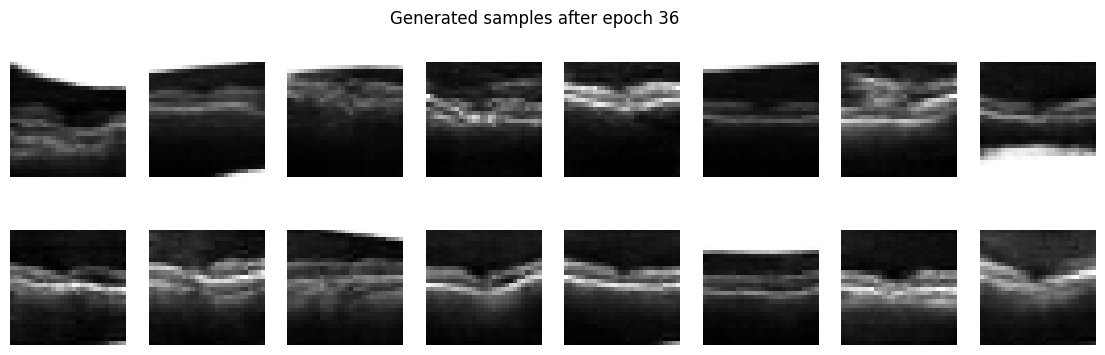

Epoch [37/40] Batch [0/762] Loss D: 0.2709 Loss G: 4.6310
Epoch [37/40] Batch [200/762] Loss D: 0.3163 Loss G: 4.2966
Epoch [37/40] Batch [400/762] Loss D: 0.7632 Loss G: 1.8477
Epoch [37/40] Batch [600/762] Loss D: 0.2052 Loss G: 4.5284


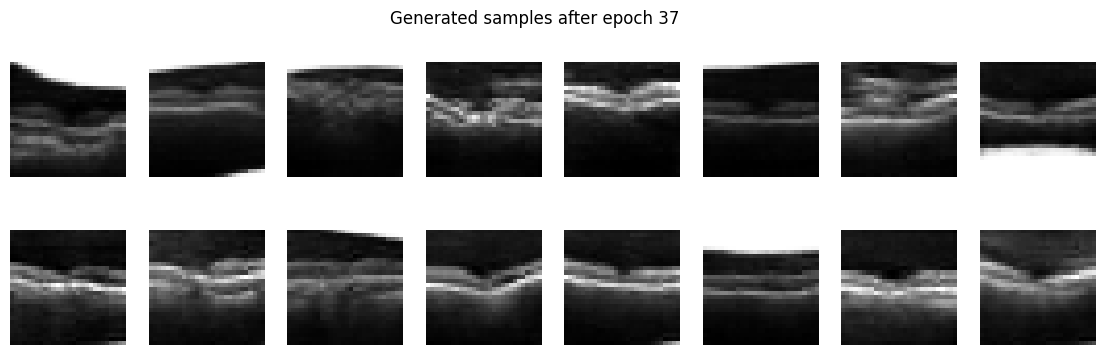

Epoch [38/40] Batch [0/762] Loss D: 0.1030 Loss G: 3.9225
Epoch [38/40] Batch [200/762] Loss D: 0.1901 Loss G: 3.7056
Epoch [38/40] Batch [400/762] Loss D: 0.1262 Loss G: 3.4677
Epoch [38/40] Batch [600/762] Loss D: 0.1419 Loss G: 4.5469


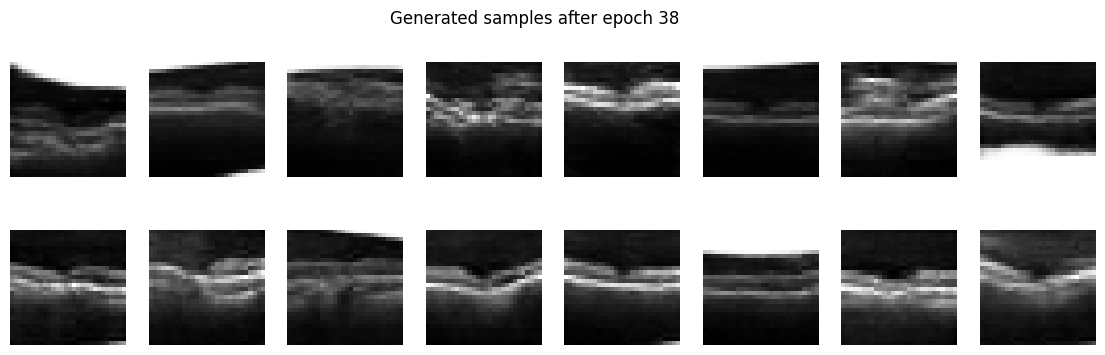

Epoch [39/40] Batch [0/762] Loss D: 0.0853 Loss G: 5.0782
Epoch [39/40] Batch [200/762] Loss D: 0.5989 Loss G: 1.6464
Epoch [39/40] Batch [400/762] Loss D: 0.0689 Loss G: 5.0083
Epoch [39/40] Batch [600/762] Loss D: 0.0956 Loss G: 4.1062


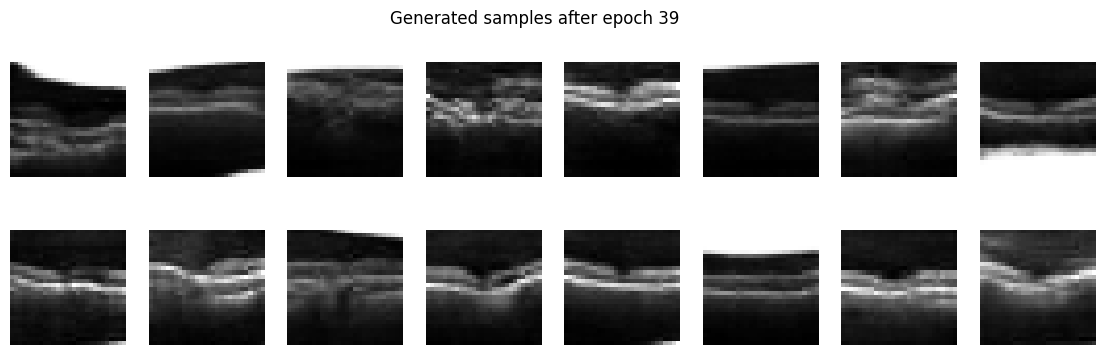

Epoch [40/40] Batch [0/762] Loss D: 0.2185 Loss G: 3.1242
Epoch [40/40] Batch [200/762] Loss D: 0.1690 Loss G: 3.6759
Epoch [40/40] Batch [400/762] Loss D: 0.1621 Loss G: 4.6670
Epoch [40/40] Batch [600/762] Loss D: 0.0626 Loss G: 3.7923


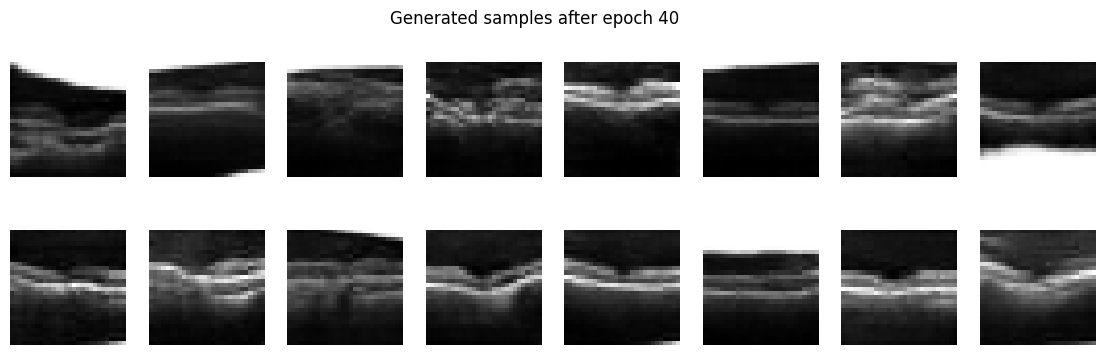

In [9]:
num_extra_epochs = 20

for epoch in range(num_epochs, num_epochs + num_extra_epochs):
    for i, (real_images, _) in enumerate(train_loader_oct):
        real_images = real_images.to(device)
        current_batch_size = real_images.size(0)

        real_labels = torch.ones(current_batch_size, 1, device=device)
        fake_labels = torch.zeros(current_batch_size, 1, device=device)

        optimizer_d.zero_grad()
        output_real = dc_discriminator(real_images)
        loss_d_real = loss_function(output_real, real_labels)

        noise = torch.randn(current_batch_size, latent_dim, device=device)
        fake_images = dc_generator(noise)
        output_fake = dc_discriminator(fake_images.detach())
        loss_d_fake = loss_function(output_fake, fake_labels)

        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        optimizer_d.step()

        optimizer_g.zero_grad()
        output_fake_for_g = dc_discriminator(fake_images)
        loss_g = loss_function(output_fake_for_g, real_labels)
        loss_g.backward()
        optimizer_g.step()

        if i % 200 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs+num_extra_epochs}] Batch [{i}/{len(train_loader_oct)}] "
                  f"Loss D: {loss_d.item():.4f} Loss G: {loss_g.item():.4f}")

    d_losses_oct.append(loss_d.item())
    g_losses_oct.append(loss_g.item())

    with torch.no_grad():
        sample_imgs = dc_generator(fixed_noise).cpu()
    fig, axes = plt.subplots(2, 8, figsize=(14, 4))
    for idx, ax in enumerate(axes.flat):
        img = sample_imgs[idx].squeeze().numpy()
        img = (img * 0.5) + 0.5
        ax.imshow(img, cmap="gray")
        ax.axis("off")
    plt.suptitle(f"Generated samples after epoch {epoch+1}")
    plt.show()

## Full Loss Curve (40 epochs total)

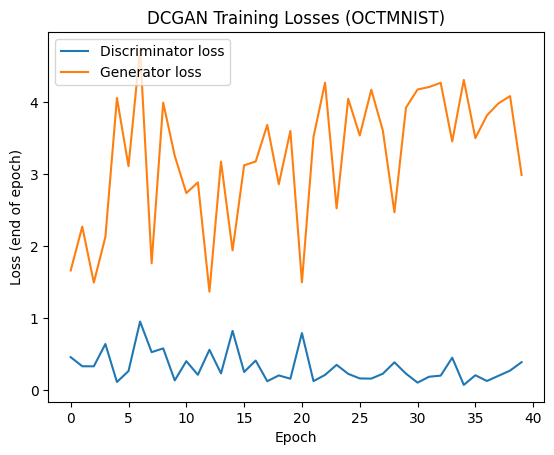

In [10]:
plt.plot(d_losses_oct, label="Discriminator loss")
plt.plot(g_losses_oct, label="Generator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (end of epoch)")
plt.legend()
plt.title("DCGAN Training Losses (OCTMNIST)")
plt.show()

## Quantitative Evaluation: Fréchet Inception Distance (FID)

FID compares the distributions of real and generated images by passing both
through a pretrained InceptionV3 network and comparing the statistics (mean and
covariance) of the resulting feature vectors. Lower FID indicates the generated
distribution is closer to the real one.

Note: InceptionV3 expects 299×299 RGB input, so our 28×28 grayscale images are
resized and channel-replicated to fit. This is a known limitation of applying FID
to small grayscale medical images — the metric was designed for natural photographic
images, so results should be interpreted as a relative/comparative signal rather
than an absolute benchmark.

In [11]:
!pip install pytorch-fid --quiet

In [12]:
import os
from PIL import Image

# Create temporary directories of real and fake images as individual PNG files,
# since pytorch-fid works off image folders.
os.makedirs("fid_real", exist_ok=True)
os.makedirs("fid_fake", exist_ok=True)

n_fid_samples = 1000

# Save real images
for i in range(n_fid_samples):
    img, _ = train_dataset[i]
    img_np = img.squeeze().numpy()
    img_np = ((img_np * 0.5) + 0.5) * 255
    Image.fromarray(img_np.astype("uint8")).save(f"fid_real/{i}.png")

# Save generated images from the trained generator
dc_generator.eval()
with torch.no_grad():
    noise = torch.randn(n_fid_samples, latent_dim, device=device)
    fake_imgs = dc_generator(noise).cpu()

for i in range(n_fid_samples):
    img_np = fake_imgs[i].squeeze().numpy()
    img_np = ((img_np * 0.5) + 0.5) * 255
    img_np = img_np.clip(0, 255)
    Image.fromarray(img_np.astype("uint8")).save(f"fid_fake/{i}.png")

print(f"Saved {n_fid_samples} real and {n_fid_samples} fake images for FID computation.")

Saved 1000 real and 1000 fake images for FID computation.


In [13]:
from pytorch_fid import fid_score

fid_value = fid_score.calculate_fid_given_paths(
    ["fid_real", "fid_fake"],
    batch_size=50,
    device=device,
    dims=2048,  # standard InceptionV3 feature dimension
)

print(f"FID score: {fid_value:.2f}")

100%|██████████| 20/20 [00:04<00:00,  4.43it/s]


FID score: 37.77


## Quantifying Texture: Vertical/Horizontal Gradient Ratio and Contrast

To assess whether the generator captures fine texture (not just coarse anatomical
layout), we compute the ratio of vertical to horizontal pixel gradients — a proxy
for horizontal banding structure — and compare pixel contrast (standard deviation)
between real and generated images.

In [14]:
def vh_gradient_ratio(images_batch):
    """Vertical-to-horizontal gradient ratio, averaged over a batch of images."""
    ratios = []
    for img in images_batch:
        img = img.squeeze()
        v_grad = np.abs(np.diff(img, axis=0)).mean()
        h_grad = np.abs(np.diff(img, axis=1)).mean()
        ratios.append(v_grad / (h_grad + 1e-8))
    return np.array(ratios)

# Real images for comparison
real_batch = np.stack([train_dataset[i][0].squeeze().numpy() for i in range(16)])
real_ratios = vh_gradient_ratio(real_batch)

# Generated images (final epoch-40 fixed-noise samples)
gen_batch = sample_imgs.numpy()
gen_ratios = vh_gradient_ratio(gen_batch)

print(f"Real images - mean v/h gradient ratio: {real_ratios.mean():.2f}")
print(f"Generated images - mean v/h gradient ratio: {gen_ratios.mean():.2f}")
print(f"Real images - pixel std: {(real_batch*255).std():.1f}")
print(f"Generated images - pixel std: {((gen_batch*0.5+0.5)*255).std():.1f}")

Real images - mean v/h gradient ratio: 5.08
Generated images - mean v/h gradient ratio: 4.05
Real images - pixel std: 116.4
Generated images - pixel std: 54.2


## Reflecting on Synthetic Data Quality

The generator reproduced OCT's coarse anatomical layout — a dark vitreous region, a bright horizontal retinal band, darker tissue below — across nearly all 16 fixed-noise samples, a non-trivial result for a shallow DCGAN trained from scratch. However, both the FID score (37.77) and the gradient-ratio/contrast metrics indicate this success is shallow rather than deep.

Both real and generated images show a vertical-to-horizontal gradient ratio well above 1 (real: 5.08, generated: 4.05), confirming the generator captured the correct *direction* of OCT's horizontal layering structure. However, the generated ratio is meaningfully lower than the real value, indicating the banding is present but less pronounced — a blurrier approximation of real layering rather than an absent one. This is reinforced far more strongly by contrast: generated images have less than half the pixel standard deviation of real images (54.2 vs. 116.4), confirming a visibly washed-out, lower-dynamic-range output.

These findings are consistent with a shallow generator (two transposed-convolution layers, no skip connections or attention) having enough capacity to represent the correct coarse structure and its general orientation, but not enough to reproduce fine intensity transitions and sharp contrast. Separately, a roughly fourfold increase in discriminator loss volatility during the second half of training offers a plausible explanation for inconsistency across individual generated samples: once the generator learned its coarse solution, the discriminator penalised it more erratically for specific latent codes.

Given more time, promising next steps would include stabilising training (e.g. label smoothing, adjusting the relative discriminator/generator update frequency) before extending it further, increasing generator depth specifically to recover contrast and fine texture, and exploring class-conditional generation given the dataset's class imbalance (normal 47.2% vs. drusen 8.0%).

The FID value of 37.77 should be interpreted cautiously: InceptionV3 was trained on natural RGB photographs, not grayscale medical images, and this domain mismatch means the score should not be compared against published FID benchmarks from unrelated natural-image GAN literature. It remains a valid relative signal for comparing models within this experiment.